In [2]:
#Setting up Installations and Imports

!pip install langchain==0.3.25 \
              langchain-core==0.3.65 \
              langchain-openai==0.3.24 \
              chromadb==1.3.4 \
              langchain-community==0.3.20 \
              pypdf==5.4.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of langchain-text-splitters to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.1/438.1 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import os

from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFDirectoryLoader, PyPDFLoader
from langchain_community.vectorstores import Chroma

In [2]:
#Organization Selection
companies =  ["GOOGL","MSFT","IBM","NVDA","AMZN"]

In [3]:
#Setting up LLM
#Loading the 'config.json' file
import json
import os

#Load the JSON file and extract values
file_name = "config.json"
with open(file_name,'r') as file:
  config = json.load(file)
  os.environ['OPENAI_API_KEY'] = config["API_KEY"]
  os.environ["OPENAI_BASE_URL"] = config["OPENAI_API_BASE"]

In [4]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_tokens=5000,
    top_p=0.95,
    frequency_penalty=1.2,
    stop_sequences=['INST']
)

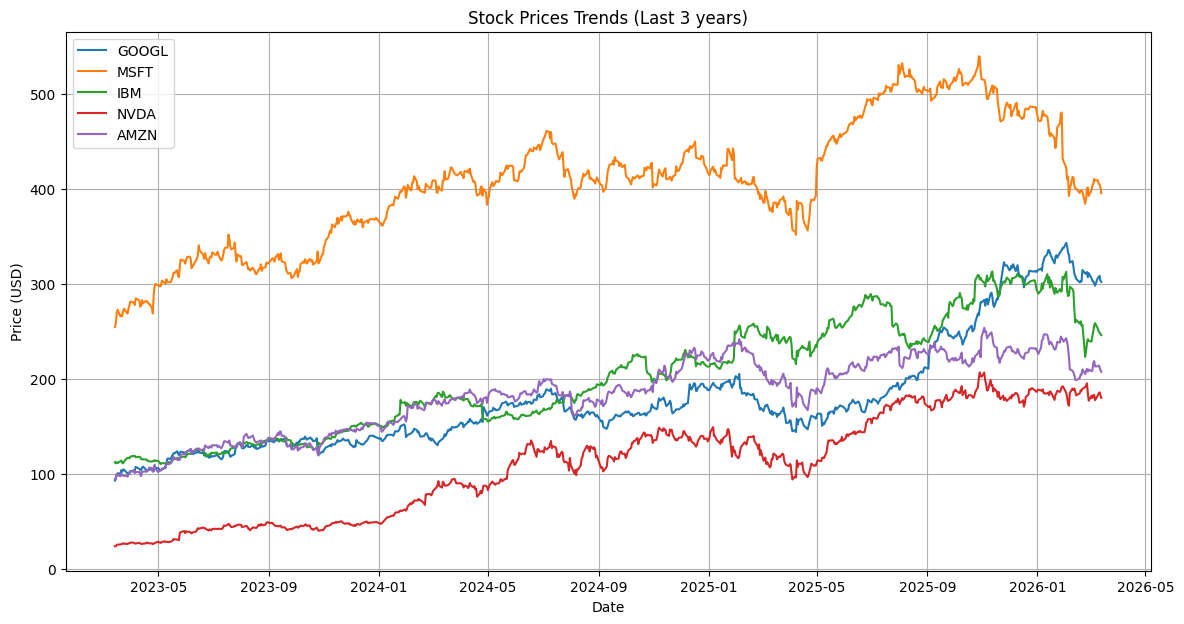

In [5]:
#Visualization and Insight Extraction

plt.figure(figsize=(14,7))

#Loop through each company and plot closing prices
for symbol in companies:
  ticker = yf.Ticker(symbol)
  data = ticker.history(period="3y")

#Plot closing price
  plt.plot(data.index, data['Close'], label=symbol)

plt.title("Stock Prices Trends (Last 3 years)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.savefig("Stock_Prices_Trends_3Y.png")
plt.show()

In [6]:
#Financial Metrics

import pandas as pd
import matplotlib.pyplot as plt

companies = ["GOOGL","MSFT","IBM","NVDA","AMZN"]
metrics_list = {}

#Fetching the financial metrics
for symbol in companies:
  ticker = yf.Ticker(symbol)
  info = ticker.info
  metrics_list[symbol] = {
      "Market Cap": info.get("marketCap", 0),
      "P/E Ratio": info.get("trailingPE", 0),
      "Dividend Yield": info.get("dividendYield", 0),
      "Beta": info.get("beta", 0),
      "Total Revenue": info.get("totalRevenue", 0)
  }

In [7]:
#Convert to DataFrame
df = pd.DataFrame(metrics_list).T

#Converting large numbers to billions for readability by dividing the whole column by 1e9
df["Market Cap"] = df["Market Cap"] / 1e9
df["Total Revenue"] = df["Total Revenue"] / 1e9
df["Dividend Yield"] = df["Dividend Yield"] * 100

df


,Market Cap,P/E Ratio,Dividend Yield,Beta,Total Revenue
GOOGL,3656.681259,27.937155,28.0,1.112,402.835997
MSFT,2939.877065,24.752815,92.0,1.108,305.453007
IBM,231.111393,22.127583,273.0,0.706,67.535000
NVDA,4380.976218,36.785713,2.0,2.375,215.938007
AMZN,2229.321073,29.004190,0.0,1.420,716.923994


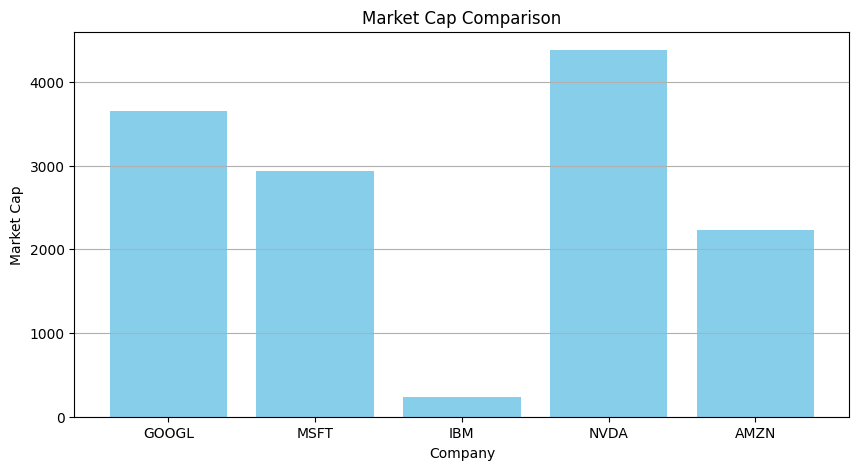

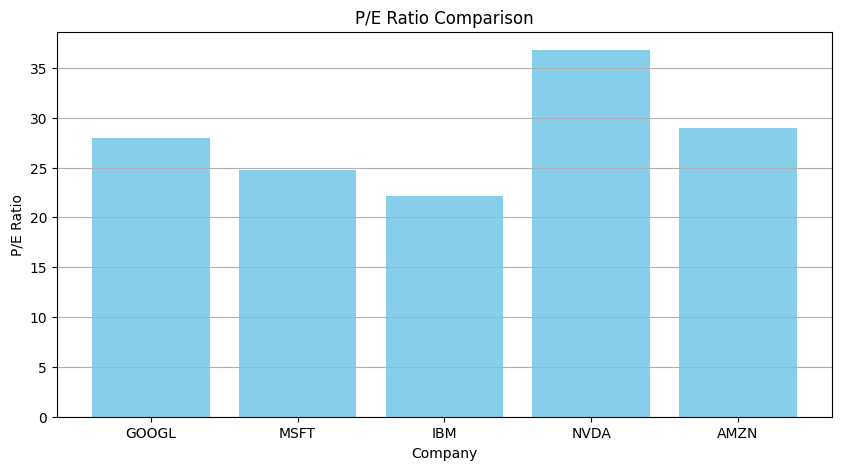

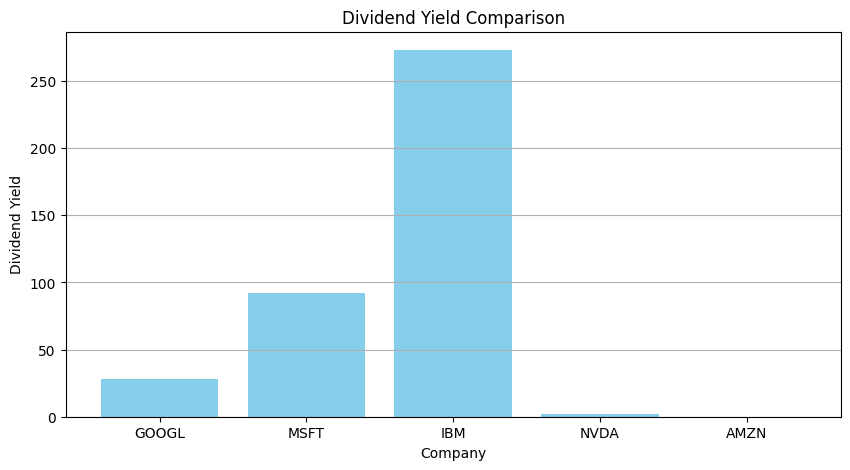

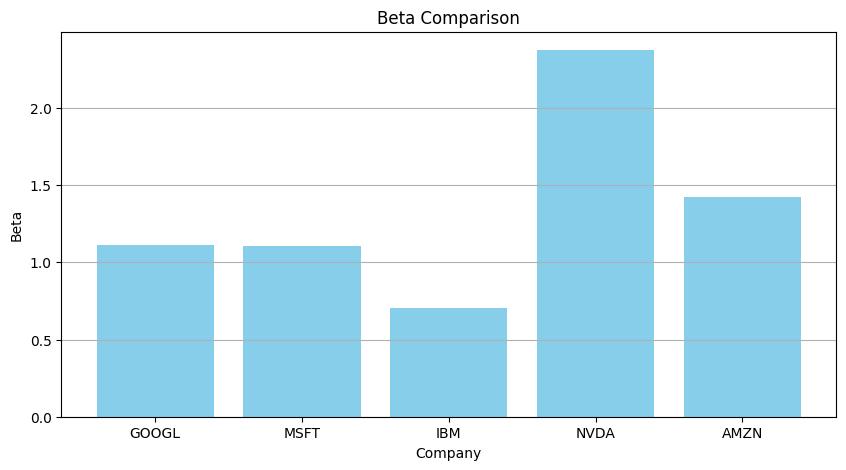

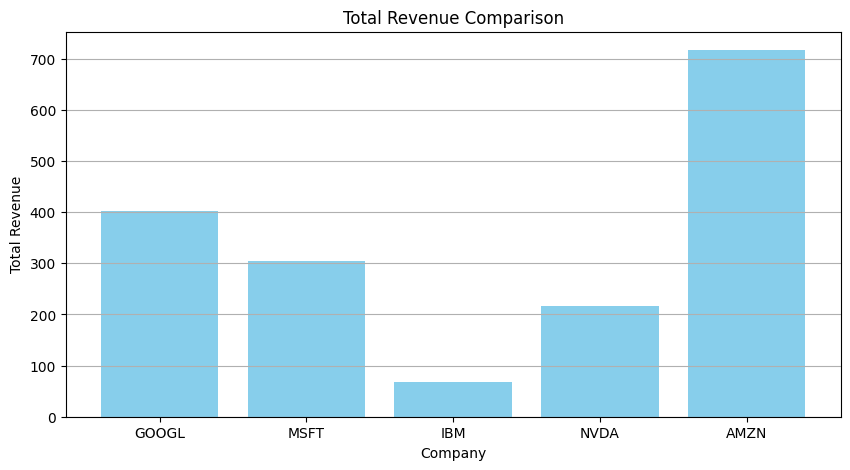

In [8]:
#Plot each metrics as a separate bar graph
metrics_to_plot = ["Market Cap","P/E Ratio","Dividend Yield","Beta","Total Revenue"]

for metric in metrics_to_plot:
  plt.figure(figsize=(10,5))
  plt.bar(df.index, df[metric], color='skyblue')
  plt.title(f"{metric} Comparison")
  plt.xlabel("Company")
  plt.ylabel(metric)
  plt.grid(axis='y')
  plt.show()

In [9]:
#RAG-Driven Analysis
#A. Loading Company AI Initiative Documents (PDFs)

#Unzipping the AI Initiatives Documents
import zipfile
with zipfile.ZipFile("Companies-AI-Initiatives.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

#Path of all AI Initiative Documents
ai_initiative_pdf_paths = [f"/content/Companies-AI-Initiatives/{file}" for file in os.listdir("/content/Companies-AI-Initiatives/")]
ai_initiative_pdf_paths

from langchain_community.document_loaders import PyPDFDirectoryLoader
loader = PyPDFDirectoryLoader(path ="/content/Companies-AI-Initiatives")

#Defining the text splitter
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base",
    chunk_size = 1000,
    chunk_overlap = 200
)

#Splitting the chunks using the text splitter
ai_initiative_chunks = loader.load_and_split(text_splitter)

#Total length of all chunks
len(ai_initiative_chunks)


62

In [10]:
#B. Vectorizing AI Initiative Documents with ChromaDB
from re import search

#Defining the 'text-embedding-ada-002' as the embedding model
from langchain_openai import OpenAIEmbeddings
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

#creating a Vectorstore, storing all the above created chunks using an embedded model
vectorstore = Chroma.from_documents(
    ai_initiative_chunks,
    embedding_model,
    collection_name="AI_Initiatives"
)

#Creating an retriever object which can fetch ten similar results from vectorstore
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k":10}
)

In [11]:
#C. Retrieving relevant Documents

user_message = "Give me the best project that 'IBM' company is working upon"

#Building the context for the query using the retrieved chunks
relevant_document_chunks = retriever.get_relevant_documents(user_message)
context_list = [d.page_content for d in relevant_document_chunks]
context_for_query = ". ".join(context_list)
len(relevant_document_chunks)

/tmp/ipykernel_1531/243693638.py:6: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  relevant_document_chunks = retriever.get_relevant_documents(user_message)


10

In [12]:
# Write a system message for an LLM to help craft a response from the provided context
qna_system_message = """
You are an AI assistant specialized in analyzing company AI initiatives.
Answer the question ONLY using the provided context.
If the answer is not present in the context, say:
"I cannot find the answer in the provided documents."
Be concise and factual.
"""
# Write an user message template which can be used to attach the context and the questions
qna_user_message_template = """
###Context
Here are some documents that are relevant to the question mentioned below.
{context}

###Question
{question}
"""

In [13]:
#Format the prompt
formatted_prompt = f"""[INST]{qna_system_message}\n
                     {'user'}: {qna_user_message_template.format(context=context_for_query, question=user_message)}
                [/INST]"""

#Make the LLM call
resp = llm.invoke(formatted_prompt)
resp.content

'I cannot find the answer in the provided documents.'

In [14]:
#Define the RAG function
def RAG(user_message):
  """
  Args:
  user_message: Takes a user input for which the response should be retrieved from the vectorDB.
  Returns:
  relevant context as per user query.
  """
  relevant_document_chunks = retriever.get_relevant_documents(user_message)
  context_list = [d.page_content for d in relevant_document_chunks]
  context_for_query = ". ".join(context_list)

  #Combine qna_system_message and qna_user_message_template to create prompt
  prompt = f"""[INST]{qna_system_message}\n
                     {'user'}: {qna_user_message_template.format(context=context_for_query, question=user_message)}
                      [/INST]"""

  #Querying the LLM
  try:
    response = llm.invoke(prompt)
  except Exception as e:
    response = f'Sorry, I encountered the following error: \n{e}'
  return response.content

In [15]:
#Test Cases
print(RAG("How is the area in which GOOGL is working different from the area in which MSFT is working?"))

print(RAG("What are the three projects on which MSFT is working upon?"))

print(RAG("What is the timeline of each project in NVDA?"))

print(RAG("What are the areas in which AMZN is investing when it comes to AI?"))

print(RAG("What are the risks associated with projects within GOOG?"))

Google (GOOGL) is focusing on advanced AI models like Gemini, which integrates multimodal capabilities across text, images, and code to enhance reasoning and generative functions in consumer and enterprise products. This includes applications such as Google Search, Gmail, and Google Assistant.

In contrast, Microsoft (MSFT) is expanding its AI initiatives primarily through Azure AI Foundry Labs and Microsoft 365 Copilot. These initiatives emphasize productivity enhancements within business workflows by embedding AI into tools like Word, Excel, Teams, and GitHub Copilot.

Thus, GOOGL's focus is on developing sophisticated multimodal foundation models for a wide range of applications while MSFT concentrates on integrating AI to improve productivity in existing software solutions.
Microsoft is working on the following three projects:

1. Azure AI Foundry Labs
2. Microsoft 365 Copilot
3. GitHub Copilot & IntelliCode
**Project G-Assist Timeline:**
- **Concept & Demo Phase:** Early prototype

In [16]:
#D. Evaluation of the RAG

# Writing a question for performing evaluations on the RAG
evaluation_test_question = "What are the three projects on which MSFT is working upon?"

#Building the context for the evaluation test question using retrieved chunks
relevant_document_chunks = retriever.get_relevant_documents(evaluation_test_question)
context_list = [d.page_content for d in relevant_document_chunks]
context_for_query = ". ".join(context_list)

#Default RAG Answer
answer = RAG(evaluation_test_question)
print(answer)

# Defining user messsage template for evaluation
evaluation_user_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""

Microsoft is working on the following three projects:

1. Azure AI Foundry Labs
2. Microsoft 365 Copilot
3. GitHub Copilot & IntelliCode


In [17]:
#1. Groundedness

# Writing the system message and the evaluation metrics for checking the groundedness
groundedness_rater_system_message = """
You are an evaluation assistant.

Your task is to determine whether the answer is fully grounded in the provided context.

Evaluation Criteria:
- If the answer is fully supported by the context → Score: 1
- If partially supported → Score: 0.5
- If not supported → Score: 0

Return:
Groundedness Score:
Explanation:
"""

# Combining groundedness_rater_system_message + llm_prompt + answer for evaluation
groundedness_prompt = f"""[INST]{groundedness_rater_system_message}\n
            {'user'}: {evaluation_user_message_template.format(context=context_for_query, question=evaluation_test_question, answer=answer)}
            [/INST]"""

#Defining a new LLM object
groundness_checker = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_tokens=500,
    top_p=0.95,
    frequency_penalty=1.2,
    stop_sequences=['INST']
)

## Using the LLM-as-Judge for evaluating Groundedness
groundness_response = groundness_checker.invoke(groundedness_prompt)
print(groundness_response.content)

Groundedness Score: 1  
Explanation: The answer is fully supported by the context, which explicitly lists the three projects Microsoft is working on: Azure AI Foundry Labs, Microsoft 365 Copilot, and GitHub Copilot & IntelliCode. Each project is described in detail within the provided context, confirming their relevance and current status as initiatives from Microsoft.


In [18]:
#2. Relevance

# Writing the system message and the evaluation metrics for checking the relevance
relevance_rater_system_message = """
You are an evaluation assistant.

Your task is to determine whether the answer directly addresses the given question.

Evaluation Criteria:
- Fully relevant → Score: 1
- Partially relevant → Score: 0.5
- Not relevant → Score: 0

Return:
Relevance Score:
Explanation:
"""

# Combining relevance_rater_system_message + llm_prompt + answer for evaluation
relevance_prompt = f"""[INST]{relevance_rater_system_message}\n
            {'user'}: {evaluation_user_message_template.format(context=context_for_query, question=evaluation_test_question, answer=answer)}
            [/INST]"""


In [19]:
# Defining a new LLM object
relevance_checker = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_tokens=500,
    top_p=0.95,
    frequency_penalty=1.2,
    stop_sequences=['INST']
)

# Using the LLM-as-Judge for evaluating Relevance
relevance_response = relevance_checker.invoke(relevance_prompt)
print(relevance_response.content)

Relevance Score: 1  
Explanation: The answer directly addresses the question by clearly listing the three projects that Microsoft is working on, which are Azure AI Foundry Labs, Microsoft 365 Copilot, and GitHub Copilot & IntelliCode.


In [20]:
#5. Scoring and Ranking

from langchain_core import documents
#Scoring and Ranking
#Fetching all the links of the documents
len(vectorstore.get()['documents'])

# Write a system message for instructing the LLM for scoring and ranking the companies
system_message = """
You are an AI investment analyst.

Your job is to:
1. Analyze the financial metrics.
2. Analyze the AI initiative documents.
3. Score each company out of 10 based on:
   - Financial strength
   - Innovation strength
   - Future growth potential
4. Rank them from best to worst.
5. Provide short justification for each ranking.
 """


# Write a user message for instructing the LLM for scoring and ranking the companies
user_message = f"""
Analyze the following companies using both financial data and AI initiatives.

Provide:
- Score out of 10
- Strength summary
- Final ranking

---
### 1. Financial Data
{df.to_string()}

---
### 2. AI Initiatives
{vectorstore.get()['documents']}
"""

In [21]:
#Formatting the prompt
formatted_prompt = f"""[INST]{system_message}\n
                {'user'}: {user_message}
                [/INST]"""

#Calling the LLM
recommendation = llm.invoke(formatted_prompt)
recommendation.content
print(recommendation.content)

### Company Analysis and Scoring

#### 1. **NVIDIA (NVDA)**
- **Score: 9/10**
- **Strength Summary:** NVIDIA is a leader in AI hardware and software, particularly with its GPUs that are essential for deep learning. Its initiatives like G-Assist and DLSS showcase strong innovation in consumer applications, enhancing user experience significantly.
  
#### 2. **Google (GOOGL)**
- **Score: 8.5/10**
- **Strength Summary:** Google has made substantial investments in AI through projects like Gemini, which integrates advanced multimodal capabilities into its products. The company’s focus on responsible AI development enhances its reputation but faces challenges from regulatory scrutiny.

#### 3. **Microsoft (MSFT)**
- **Score: 8/10**
- **Strength Summary:** Microsoft has integrated AI across its product suite effectively with initiatives like Azure Foundry Labs and Microsoft Copilot, driving productivity improvements for enterprises. However, it faces competition from other tech giants.

#### 

In [22]:
#6. Summary and Future Scope

#Summary / Observations about this Project
In this project, we tried to improve traditional investment analysis by combining financial data with information from company documents about their AI initiatives.
Usually, investors focus mainly on financial indicators such as market cap, revenue, P/E ratio, and stock price trends.
While these metrics are important, they mostly reflect the company’s past performance and may not fully show its future potential.

Through this project, we used a RAG-based system to retrieve information from PDF documents and combine it with financial metrics.
This helped in understanding not only how companies are performing financially but also how much they are investing in innovation and artificial intelligence.
One important observation was that companies with strong AI initiatives may have better long-term potential even if their current financial numbers are similar to others.
During the implementation, some difficulties were faced while processing PDF files, splitting the documents into meaningful chunks, and ensuring that the generated answers were based on the retrieved context.


SyntaxError: invalid character '’' (U+2019) (3877781377.py, line 6)

In [ ]:
#Future Scope of this Project (2 Marks)
This project can be further improved by including more sources of information such as financial news, market analysis reports,
and real-time stock updates. Adding more financial indicators like profit margins, R&D expenditure, or growth rate could also make the analysis more detailed and useful.

Another improvement would be to develop an interactive interface where users can easily compare companies and view insights visually.
In the future, the system could be expanded into a complete decision-support tool for investors that automatically analyzes companies based on both financial strength and
their focus on emerging technologies like artificial intelligence.